# **06. Diversification and Correlations**
## **Overview**

This notebook explores the process of using the historical data of an asset to compute its expected returns and variance, then moving on to the only 'free lunch' in investing: how diversification can reduce risk and augment your risk-adjusted returns. It then later explores how the effects of diversification break down during extraordinary regimes and economic conditions, and how to avoid it.

### Learning Objectives  
By the end of this notebook, you will be able to:  
1. Estimate expected returns and return volatility from historical price data.
2. Simulate future asset prices using Monte Carlo methods.
3. Understand how diversification reduces idiosyncratic risk.
4. Explain why diversification becomes less effective during market crises.
5. Compare correlation structures across normal and stressed market environments.

## Background

One of the oldest ideas in finance is deceptively simple:  
> **Don't put all your eggs in one basket!**

Diversification works because different assets rarely move perfectly together. Losses in one investment can often be offset by gains in another.  



Modern Portfolio Theory suggests that investors can reduce portfolio risk by combining assets whose returns are **not perfectly correlated**.

The total risk of an investment portfolio can be separated into:  
- **Idiosyncratic (diversifiable) risk** – company-specific events that can largely be eliminated through diversification.
- **Systematic (market) risk** – economy-wide shocks that affect nearly all assets simultaneously.

Under normal market conditions, diversification substantially lowers portfolio volatility. 



**But, this principle has an important limitation!**

During major financial crises, assets that normally behave independently suddenly begin moving together. Correlations increase dramatically, causing diversification benefits to disappear precisely when investors need them the most.

However, during financial crises, correlations between risky assets often increase dramatically, reducing the effectiveness of diversification precisely when investors need it most.

In this notebook, we'll build that intuition from data.

We'll begin by estimating historical return distributions for several assets, simulate thousands of possible future outcomes, then progressively diversify portfolios to observe how portfolio risk changes. Finally, we'll revisit three major market crises and examine how cross-asset correlations changed under stress.  

### Part 1 — Historical Return Distributions
First, we need to gather the historical returns of a particular of a security (e.g. Apple stock).
#### **1. Historical returns are realizations from some underlying random variable**  
We treat the return of a security, $R$, as a random variable:
$$
R ∼ \text{some unknown distribution}
$$

This implies that the return has population characteristics such as:

- Expected return:
$$
E(R) = \mu
$$

- Variance:
$$
Var(R) = \sigma^2
$$
Even if we do not know the exact distribution, these moments can still be defined.

##### Time frame of returns

The time frame for the returns we choose can be daily, monthly, yearly or any other time frames.

The shorter the time frame, i.e. daily, the more data points we have, but also the more noise we introduce into the sample set. The trade-off is that daily returns exhibit more market microstructure effects and stronger departures from the independent and identically distributed assumptions (e.g., volatility clustering), so higher frequency isn't always better for every application.

##### Returns vs Price




##### **2. We estimate these moments from historical data**
Given our data set $\{r_1, r_2, r_3, \cdots, r_n\}$ we estimate:
1. **Expected return** $E(R)$
2. **Variance** $Var(R)$
Mathematically,
$$\hat{\mu} = \frac{1}{n} \sum\limits_{i=1}^{n} r_i$$
and
$$\hat{\sigma}^2 = \frac{1}{n-1} \sum\limits_{i=1}^{n} (r_i - \hat{\mu})^2$$
where $r_i$ is the return for a specific period.
These summarize the center and spread of historical returns.
##### **3. We do not assume the distribution of historical returns for a specific security.**
Instead, we may say:
> Future returns are generated by an unknown probability distribution with characteristics that can be estimated from historical data.

This approach is called nonparametric moment estimation (or distribution-free estimation of moments)

For example, historical returns may have:
- fat tails (more extreme events than a normal distribution predicts)
- skewness (more large losses than gains)
- volatility clustering
- changing variance over time

So assuming normality may be unrealistic.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
aapl = pd.read_csv("../data/aapl_us_m.csv")
aapl["Date"] = pd.to_datetime(aapl["Date"])

aapl = (
    aapl
    .set_index("Date")
    .sort_index()
)

aapl.head()

,Open,High,Low,Close,Volume
Date,,,,,
1984-09-30,0.118208,0.129286,0.109647,0.111787,2.146054e+09
1984-10-31,0.111448,0.121787,0.100337,0.110723,3.563056e+09
1984-11-30,0.111448,0.118208,0.097495,0.109998,3.370058e+09
1984-12-31,0.109998,0.130362,0.108559,0.129646,3.455021e+09
1985-01-31,0.129646,0.138570,0.124278,0.129286,6.366416e+09


In [70]:
monthly_log_returns = np.log(
    aapl["Close"] /
    aapl["Close"].shift(1)
).dropna()
# monthly_log_returns = monthly_log_returns.to_frame(
#     name="AAPL_Log_Return"
# )
#monthly_log_returns.head()

In [71]:
mean_return = monthly_log_returns.mean()
variance = monthly_log_returns.var()
volatility = monthly_log_returns.std()
annual_return = mean_return * 12
annual_volatility = volatility * np.sqrt(12)
print("Mean return", mean_return, "\nVariance", variance, "\nAnnual Return:", annual_return, "\nAnnual Volatility:", annual_volatility)

Mean return 0.015939287363504633 
Variance 0.014878876912209961 
Annual Return: 0.1912714483620556 
Annual Volatility: 0.42254765760387253


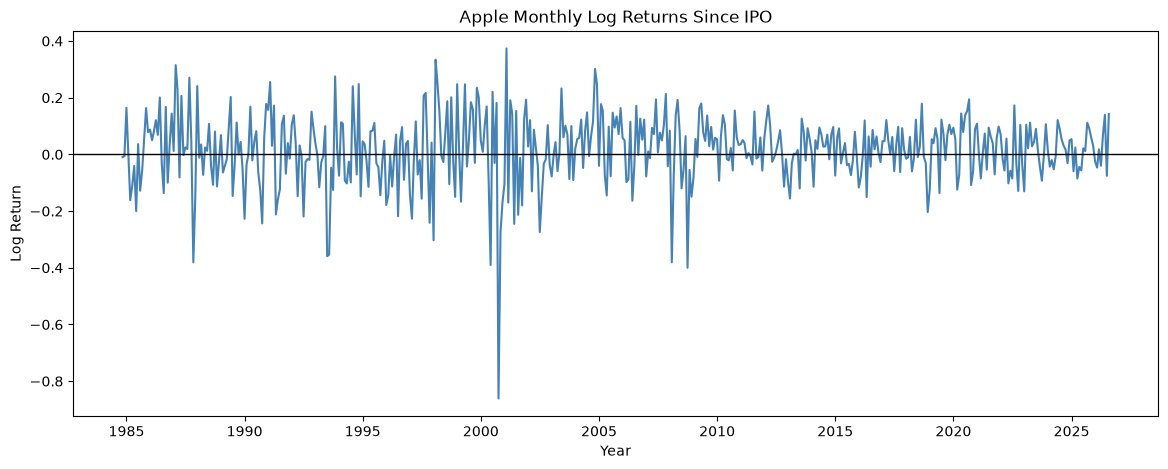

In [72]:
plt.figure(figsize=(14,5))

plt.plot(
    monthly_log_returns,
    color="steelblue"
)

plt.axhline(
    0,
    color="black",
    linewidth=1
)

plt.title(
    "Apple Monthly Log Returns Since IPO"
)

plt.ylabel(
    "Log Return"
)

plt.xlabel(
    "Year"
)

plt.show()

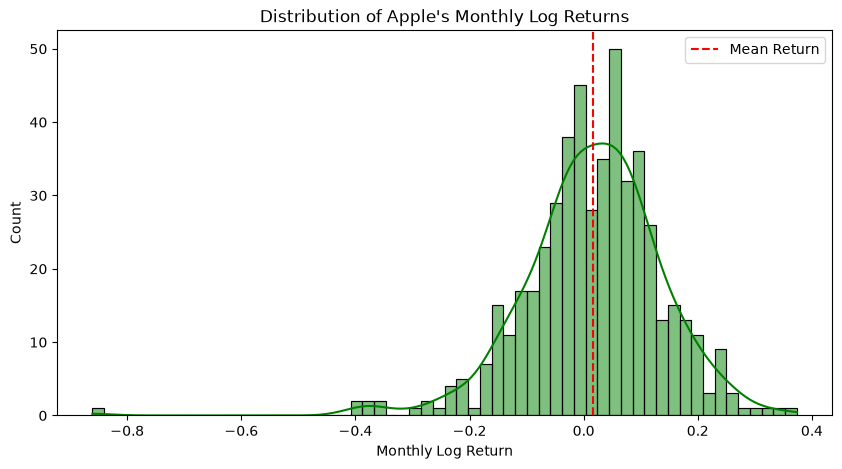

In [73]:
plt.figure(figsize=(10,5))

sns.histplot(
    monthly_log_returns,
    bins=60,
    kde=True,
    color="green"
)

plt.axvline(
    mean_return,
    color="red",
    linestyle="--",
    label="Mean Return"
)

plt.title(
    "Distribution of Apple's Monthly Log Returns"
)

plt.xlabel(
    "Monthly Log Return"
)

plt.legend()

plt.show()

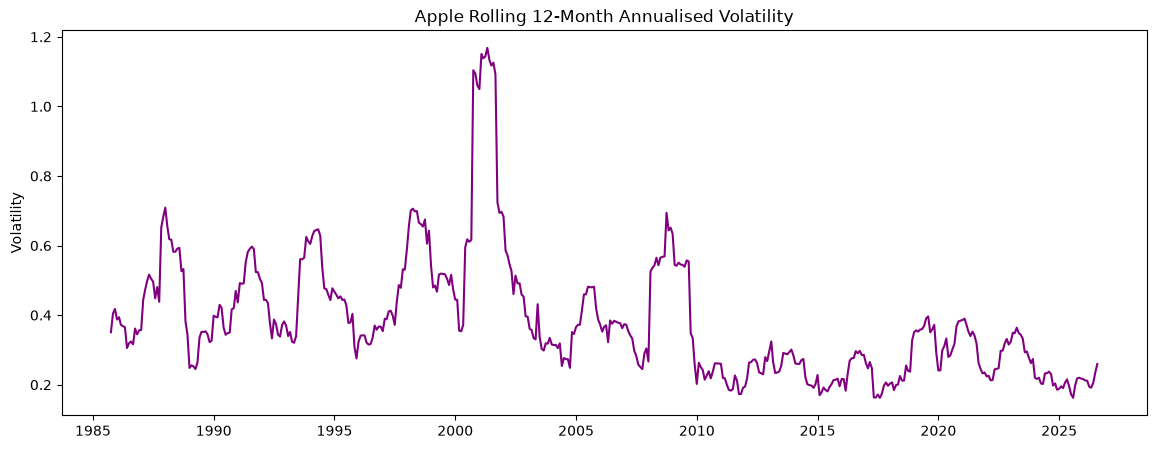

In [74]:
rolling_vol = (
    monthly_log_returns
    .rolling(12)
    .std()
    * np.sqrt(12)
)
plt.figure(figsize=(14,5))

plt.plot(
    rolling_vol,
    color="purple"
)

plt.title(
    "Apple Rolling 12-Month Annualised Volatility"
)

plt.ylabel(
    "Volatility"
)

plt.show()

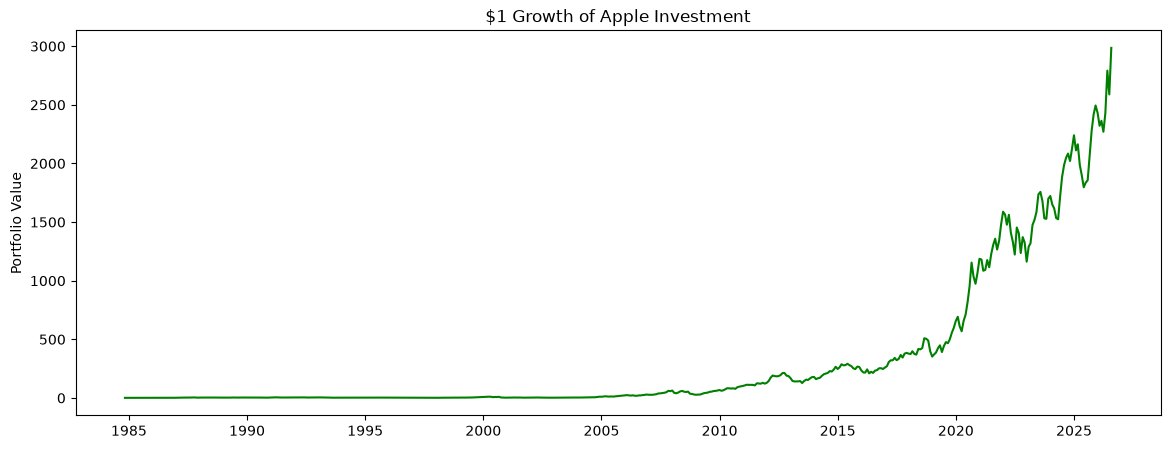

In [75]:
wealth = np.exp(
    monthly_log_returns.cumsum()
)

plt.figure(figsize=(14,5))

plt.plot(
    wealth,
    color="green"
)

plt.title(
    "$1 Growth of Apple Investment"
)

plt.ylabel(
    "Portfolio Value"
)

plt.show()

In [76]:
params = pd.DataFrame({
    "Mean Return": [monthly_log_returns.mean()],
    "Variance": [monthly_log_returns.var()],
    "Volatility": [monthly_log_returns.std()]
},
index=["AAPL"])

params

,Mean Return,Variance,Volatility
AAPL,0.015939,0.014879,0.121979


In [77]:
mu = monthly_log_returns.mean()
sigma = monthly_log_returns.std()